# 02 — Policy Iteration
**Week 4 | Dynamic Programming**

**Policy Iteration** alternates between two steps until the policy stabilises:

1. **Policy Evaluation**: compute V^π for the current policy
2. **Policy Improvement**: greedily update π using V^π

Guaranteed to converge to the optimal policy π* in finite MDPs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    ACTION_SYMBOLS = {0:'↑', 1:'↓', 2:'←', 3:'→'}
    def __init__(self, size=5):
        self.size=size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits={(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        r,c = divmod(s, self.size)
        dr,dc = self.ACTIONS[a]
        nr=max(0,min(self.size-1,r+dr)); nc=max(0,min(self.size-1,c+dc))
        ns=nr*self.size+nc
        if (nr,nc)==self.goal:      return [(1.0,ns,+10.0,True)]
        if (nr,nc) in self.pits:    return [(1.0,ns,-5.0,True)]
        return [(1.0,ns,-0.1,False)]

env = GridWorld()

In [2]:
def policy_eval(env, policy, gamma=0.99, theta=1e-6):
    V = np.zeros(env.n_states())
    while True:
        delta = 0
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            v = sum(policy[s,a] * sum(p*(r + (0 if d else gamma*V[ns]))
                    for p,ns,r,d in env.transitions(s,a))
                    for a in range(env.n_actions()))
            V_new[s] = v; delta = max(delta, abs(v - V[s]))
        V = V_new
        if delta < theta: break
    return V

def policy_improvement(env, V, gamma=0.99):
    policy = np.zeros((env.n_states(), env.n_actions()))
    for s in range(env.n_states()):
        Q_s = np.array([sum(p*(r + (0 if d else gamma*V[ns]))
                        for p,ns,r,d in env.transitions(s,a))
                        for a in range(env.n_actions())])
        best_actions = np.where(Q_s == Q_s.max())[0]
        policy[s, best_actions] = 1.0 / len(best_actions)
    return policy

def policy_iteration(env, gamma=0.99):
    policy = np.ones((env.n_states(), env.n_actions())) / env.n_actions()
    policy_history = [policy.argmax(axis=1).copy()]
    V_history = []
    iteration = 0
    while True:
        V = policy_eval(env, policy, gamma)
        V_history.append(V.copy())
        new_policy = policy_improvement(env, V, gamma)
        if np.array_equal(new_policy.argmax(1), policy.argmax(1)):
            print(f"Policy iteration converged in {iteration+1} iterations")
            return policy, V, policy_history, V_history
        policy = new_policy
        policy_history.append(policy.argmax(axis=1).copy())
        iteration += 1

In [3]:
opt_policy, opt_V, pol_hist, V_hist = policy_iteration(env)

Policy iteration converged in 3 iterations


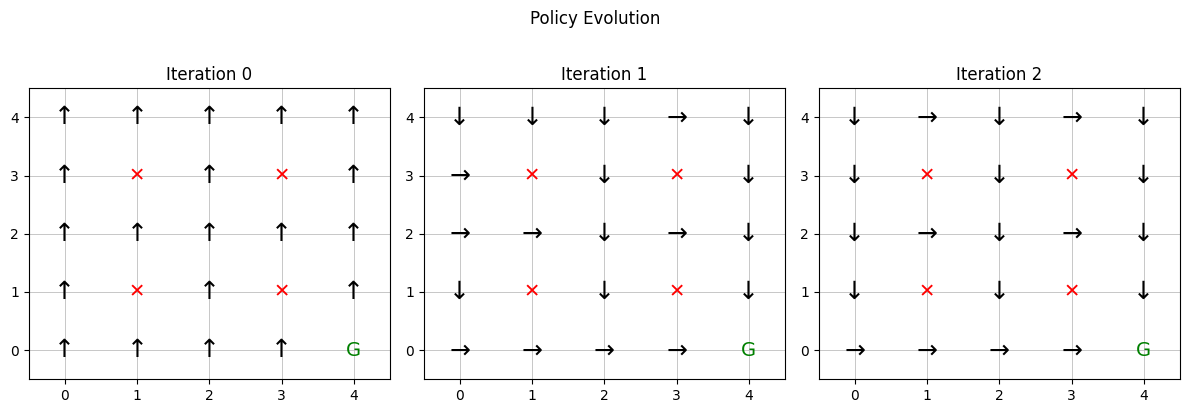

In [4]:
# Show policy evolution
n_iters = len(pol_hist)
fig, axes = plt.subplots(1, n_iters, figsize=(4*n_iters, 4))
if n_iters == 1: axes = [axes]
for ax, (pi, title) in enumerate(zip(pol_hist, [f'Iter {i}' for i in range(n_iters)])):
    axes[ax].set_xlim(-0.5, 4.5); axes[ax].set_ylim(-0.5, 4.5)
    axes[ax].set_xticks(range(5)); axes[ax].set_yticks(range(5))
    axes[ax].grid(True, linewidth=0.5)
    for s in range(25):
        r, c = divmod(s, 5)
        if (r,c) == env.goal:         axes[ax].text(c, 4-r, 'G', ha='center', va='center', fontsize=14, color='green')
        elif (r,c) in env.pits:       axes[ax].text(c, 4-r, '✕', ha='center', va='center', fontsize=14, color='red')
        else:                         axes[ax].text(c, 4-r, env.ACTION_SYMBOLS[pol_hist[ax][s]], ha='center', va='center', fontsize=18)
    axes[ax].set_title(f'Iteration {ax}')
plt.suptitle('Policy Evolution', y=1.02); plt.tight_layout(); plt.show()

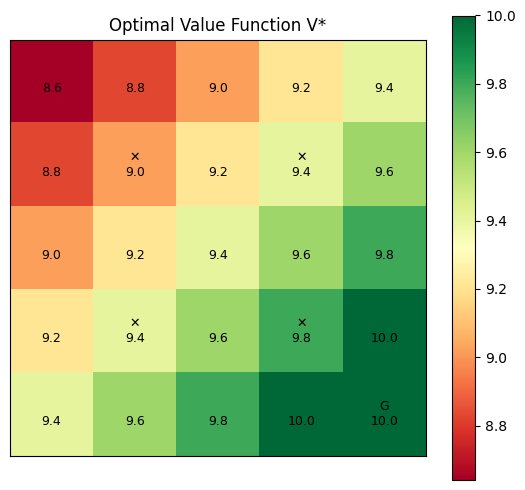

In [5]:
# Final optimal value function
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(opt_V.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=ax)
for s in range(25):
    r,c = divmod(s,5)
    label = 'G' if (r,c)==env.goal else ('✕' if (r,c) in env.pits else '')
    ax.text(c, r, f'{label}\n{opt_V[s]:.1f}', ha='center', va='center', fontsize=9)
ax.set_title('Optimal Value Function V*'); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## ✅ Exercises
1. Add a 'treasure' cell at (2,2) giving +3 reward (non-terminal). Does the optimal policy change to seek it?
2. Change pits to non-terminal (-5 reward but keep going). How does the policy change?
3. **Challenge**: implement **modified policy iteration** — only do k=5 steps of evaluation per improvement instead of full convergence. Does it still find the optimal policy?

# Answer

### Exercise 1: Add a 'treasure' cell

Here is a copy of the `GridWorld` environment, modified to include a non-terminal treasure cell at `(2,2)` that gives a `+3` reward. We'll then re-run policy iteration using the existing functions to see how the optimal policy and value function change.

In [10]:
class GridWorldWithTreasure:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    ACTION_SYMBOLS = {0:'↑', 1:'↓', 2:'←', 3:'→'}
    def __init__(self, size=5):
        self.size=size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits={(1,1),(1,3),(3,1),(3,3)}
        self.treasure={(2,2)} # Added treasure
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        r,c = divmod(s, self.size)
        dr,dc = self.ACTIONS[a]
        nr=max(0,min(self.size-1,r+dr)); nc=max(0,min(self.size-1,c+dc))
        ns=nr*self.size+nc
        if (nr,nc)==self.goal:      return [(1.0,ns,+10.0,True)]
        if (nr,nc) in self.pits:    return [(1.0,ns,-5.0,True)]
        if (nr,nc) in self.treasure: return [(1.0,ns,+3.0,False)] # Added treasure transition
        return [(1.0,ns,-0.1,False)]

env_treasure = GridWorldWithTreasure()

In [11]:
opt_policy_t, opt_V_t, pol_hist_t, V_hist_t = policy_iteration(env_treasure)

Policy iteration converged in 5 iterations


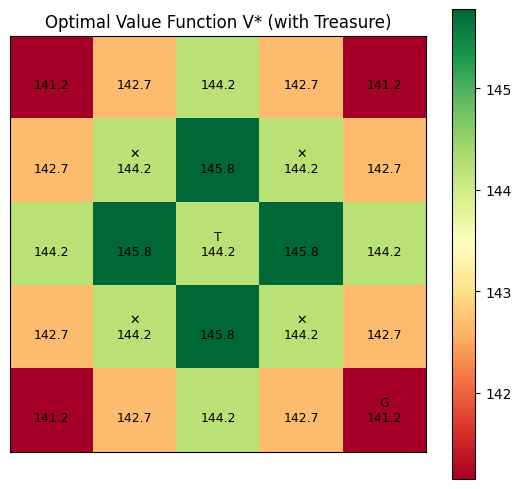

In [12]:
# Final optimal value function with treasure
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(opt_V_t.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=ax)
for s in range(25):
    r,c = divmod(s,5)
    # Add 'T' for treasure
    label = 'G' if (r,c)==env_treasure.goal else ('✕' if (r,c) in env_treasure.pits else ('T' if (r,c) in env_treasure.treasure else ''))
    ax.text(c, r, f'{label}\n{opt_V_t[s]:.1f}', ha='center', va='center', fontsize=9)
ax.set_title('Optimal Value Function V* (with Treasure)'); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

yes the policy change as we can see in the optimal value func

In [14]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

class GridWorld_custom:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    ACTION_SYMBOLS = {0:'↑', 1:'↓', 2:'←', 3:'→'}
    def __init__(self, size=5):
        self.size=size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits={(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        r,c = divmod(s, self.size)
        dr,dc = self.ACTIONS[a]
        nr=max(0,min(self.size-1,r+dr)); nc=max(0,min(self.size-1,c+dc))
        ns=nr*self.size+nc
        if (nr,nc)==self.goal:      return [(1.0,ns,+10.0,True)]
        if (nr,nc) in self.pits:    return [(1.0,ns,-5.0,False)]
        return [(1.0,ns,-0.1,False)]

env_c = GridWorld_custom()

In [17]:
opt_policy, opt_V, pol_hist, V_hist = policy_iteration(env_c)

Policy iteration converged in 3 iterations


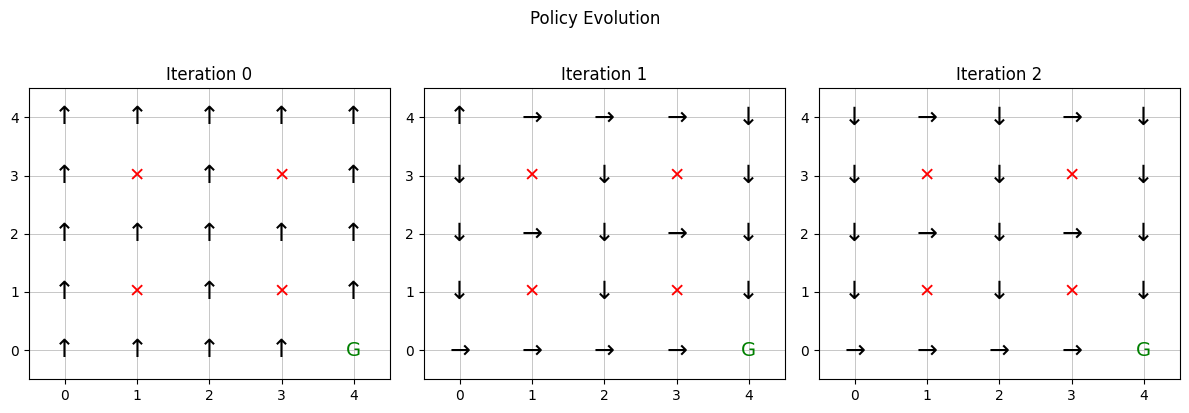

In [20]:
# Show policy evolution
n_iters = len(pol_hist)
fig, axes = plt.subplots(1, n_iters, figsize=(4*n_iters, 4))
if n_iters == 1: axes = [axes]
for ax, (pi, title) in enumerate(zip(pol_hist, [f'Iter {i}' for i in range(n_iters)])):
    axes[ax].set_xlim(-0.5, 4.5); axes[ax].set_ylim(-0.5, 4.5)
    axes[ax].set_xticks(range(5)); axes[ax].set_yticks(range(5))
    axes[ax].grid(True, linewidth=0.5)
    for s in range(25):
        r, c = divmod(s, 5)
        if (r,c) == env_c.goal:         axes[ax].text(c, 4-r, 'G', ha='center', va='center', fontsize=14, color='green')
        elif (r,c) in env_c.pits:       axes[ax].text(c, 4-r, '✕', ha='center', va='center', fontsize=14, color='red')
        else:                         axes[ax].text(c, 4-r, env.ACTION_SYMBOLS[pol_hist[ax][s]], ha='center', va='center', fontsize=18)
    axes[ax].set_title(f'Iteration {ax}')
plt.suptitle('Policy Evolution', y=1.02); plt.tight_layout(); plt.show()

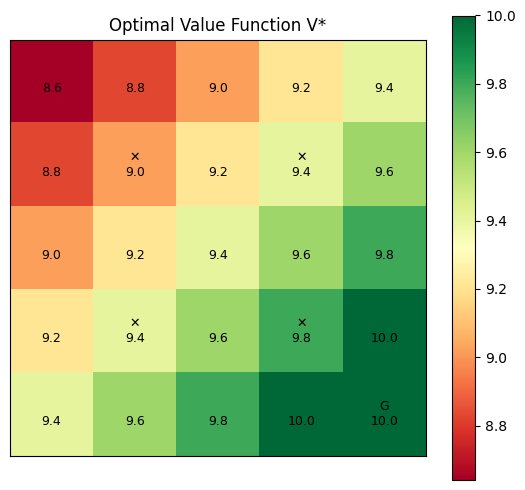

In [21]:
# Final optimal value function
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(opt_V.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=ax)
for s in range(25):
    r,c = divmod(s,5)
    label = 'G' if (r,c)==env_c.goal else ('✕' if (r,c) in env_c.pits else '')
    ax.text(c, r, f'{label}\n{opt_V[s]:.1f}', ha='center', va='center', fontsize=9)
ax.set_title('Optimal Value Function V*'); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

the "Optimal Value Function" plot that the agent now learns a policy to navigate around the pits. Since they are no longer a game-ending trap, the values of the states near the pits are not as drastically negative, and the agent is willing to travel closer to them if it provides a shorter path to the goal.

Below is a corrected implementation. We'll create:
1. A new `policy_eval_k` function that performs exactly `k` sweeps over the state space.
2. A `modified_policy_iteration` function that calls `policy_eval_k` inside its main loop instead of the fully-converging `policy_eval`.

In [28]:
def policy_eval_k(env, policy, V, k=5, gamma=0.99):
    """Performs k sweeps of policy evaluation."""
    for _ in range(k):
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            # Calculate the value of state s under the current policy
            v = sum(policy[s,a] * sum(p*(r + (0 if d else gamma*V[ns]))
                    for p,ns,r,d in env.transitions(s,a))
                    for a in range(env.n_actions()))
            V_new[s] = v
        V = V_new
    return V

def modified_policy_iteration(env, k=5, gamma=0.99):
    """Modified policy iteration with k evaluation steps."""
    policy = np.ones((env.n_states(), env.n_actions())) / env.n_actions()
    V = np.zeros(env.n_states()) # Start with V=0
    policy_history = [policy.argmax(axis=1).copy()]
    V_history = []
    iteration = 0
    while True:
        V = policy_eval_k(env, policy, V, k=k, gamma=gamma) # k steps of evaluation
        V_history.append(V.copy())
        new_policy = policy_improvement(env, V, gamma)
        
        if np.array_equal(new_policy.argmax(1), policy.argmax(1)):
            print(f"Modified Policy Iteration (k={k}) converged in {iteration+1} iterations.")
            return new_policy, V, policy_history, V_history
        
        policy = new_policy
        policy_history.append(policy.argmax(axis=1).copy())
        iteration += 1
        if iteration > 50: # Safeguard against non-convergence
            print("Stopping after 50 iterations.")
            return policy, V, policy_history, V_history

In [29]:
# Run modified policy iteration on the original environment
opt_policy_m, opt_V_m, _, _ = modified_policy_iteration(env, k=5)

Modified Policy Iteration (k=5) converged in 5 iterations.


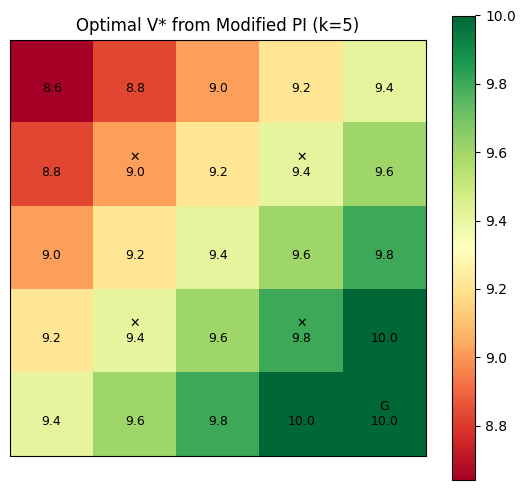

In [30]:
# Plot the final value function
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(opt_V_m.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=ax)
for s in range(25):
    r,c = divmod(s,5)
    label = 'G' if (r,c)==env.goal else ('✕' if (r,c) in env.pits else '')
    ax.text(c, r, f'{label}\n{opt_V_m[s]:.1f}', ha='center', va='center', fontsize=9)
ax.set_title(f'Optimal V* from Modified PI (k=5)'); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()